# SVM Model and Final Comparison

## Objective

In this notebook, we train and evaluate an SVM classifier for student performance classification, then compare its performance with Logistic Regression, Decision Tree, and Random Forest.

In [12]:
# Import required libraries
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC


In [13]:
# Load shared artifacts created in the shared notebook
base_dir = Path("..")
data_split_path = base_dir / "data_split.pkl"

if not data_split_path.exists():
    raise FileNotFoundError(f"Missing required file: {data_split_path}")

X_train, X_test, y_train, y_test = joblib.load(data_split_path)

print("Shared files loaded successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Shared files loaded successfully.
X_train shape: (5285, 19)
X_test shape: (1322, 19)


In [14]:
# Rebuild the shared preprocessing pipeline to avoid version issues with pickled sklearn objects
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)


Processed X_train shape: (5285, 40)
Processed X_test shape: (1322, 40)


In [15]:
# Display target class names for reference
class_names = ["Fail", "Pass"]

print("Target classes:", class_names)


Target classes: ['Fail', 'Pass']


## SVM Model Training

In this section, we train a baseline Support Vector Machine classifier using the preprocessed data.

In [16]:
# Initialize SVM model
svm_model = SVC(kernel="rbf", random_state=42)

# Train model
svm_model.fit(X_train_processed, y_train)

print("SVM model trained successfully.")


SVM model trained successfully.


## Model Evaluation

In this section, we evaluate the baseline SVM model using accuracy, classification report, and confusion matrix.

In [17]:
# Predict on test data
y_pred = svm_model.predict(X_test_processed)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Accuracy: 0.9636913767019667

Classification Report:
              precision    recall  f1-score   support

        Fail       0.97      0.99      0.98       997
        Pass       0.96      0.89      0.92       325

    accuracy                           0.96      1322
   macro avg       0.96      0.94      0.95      1322
weighted avg       0.96      0.96      0.96      1322

Confusion Matrix:
[[984  13]
 [ 35 290]]


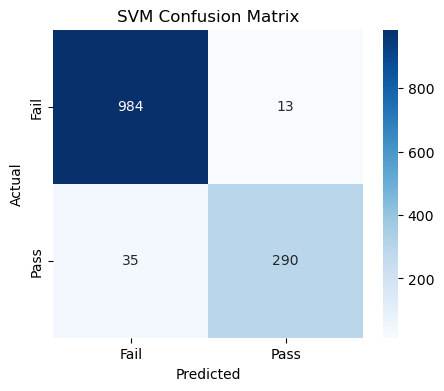

In [18]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()


### Interpretation of Results

The baseline SVM model provides a strong starting point. Next, we tune the hyperparameters to check whether performance can be improved further.

## Hyperparameter Tuning (Grid Search)

In [19]:
# Define parameter grid
param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10],
        "gamma": ["scale", 0.01, 0.1, 1]
    }
]

# Initialize model
svm = SVC(random_state=42)

# Grid search
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
grid_search.fit(X_train_processed, y_train)

# Best model
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", round(grid_search.best_score_, 4))


Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Best Cross-Validation Accuracy: 0.9816


In [20]:
# Predict using tuned model
y_pred_best = best_model.predict(X_test_processed)

# Accuracy
accuracy_best = accuracy_score(y_test, y_pred_best)
print("Tuned Accuracy:", accuracy_best)

# Report
print("\nClassification Report (Tuned):")
print(classification_report(y_test, y_pred_best, target_names=class_names, zero_division=0))

svm_metrics = {
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_best, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_best, average="weighted", zero_division=0),
}

pd.DataFrame([svm_metrics])


Tuned Accuracy: 0.9773071104387292

Classification Report (Tuned):
              precision    recall  f1-score   support

        Fail       0.98      0.99      0.99       997
        Pass       0.98      0.93      0.95       325

    accuracy                           0.98      1322
   macro avg       0.98      0.96      0.97      1322
weighted avg       0.98      0.98      0.98      1322



,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.977307,0.977308,0.977307,0.977111


##### Interpretation of Tuned Model

The tuned SVM model is used as the final SVM result for the comparison table below.

## Final Model Comparison

In [23]:
comparison_rows = [
    {"Model": "Logistic Regression", "Accuracy": 0.881241, "Precision": 0.881143, "Recall": 0.881241, "F1-Score": 0.880965},
    {"Model": "Decision Tree", "Accuracy": 0.8487, "Precision": 0.84, "Recall": 0.85, "F1-Score": 0.85},
    {"Model": "Random Forest", "Accuracy": 0.8986, "Precision": 0.90, "Recall": 0.89, "F1-Score": 0.88},
    svm_metrics
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.881241,0.881143,0.881241,0.880965
1,Decision Tree,0.848700,0.840000,0.850000,0.850000
2,Random Forest,0.898600,0.900000,0.890000,0.880000
3,SVM,0.977307,0.977308,0.977307,0.977111


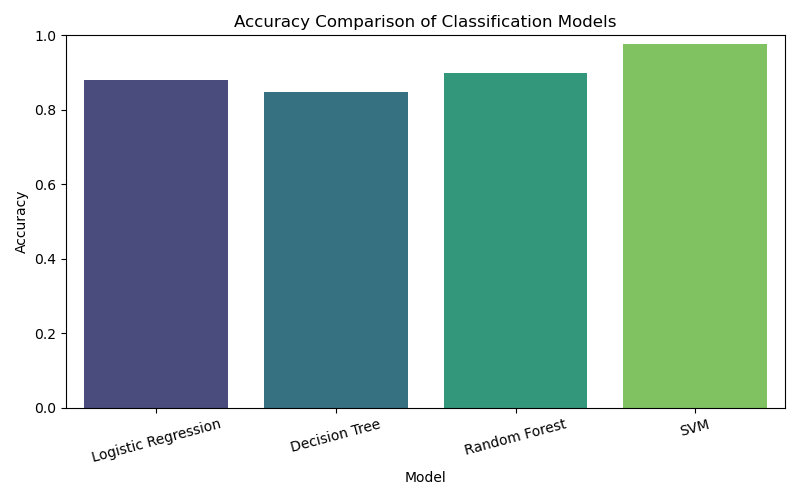

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", hue="Model", palette="viridis", legend=False)
plt.title("Accuracy Comparison of Classification Models")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Final Conclusion

Based on the comparison table, Logistic Regression and SVM achieved the strongest overall performance on this dataset, while Decision Tree and Random Forest performed comparatively lower. This suggests that the dataset is highly suitable for well-regularized linear or margin-based classifiers after preprocessing.